Scanning film 1 of 4 at origin (1.0, 1.0) mm
Scanning film 2 of 4 at origin (26.0, 1.0) mm
Scanning film 3 of 4 at origin (51.0, 1.0) mm
Scanning film 4 of 4 at origin (76.0, 1.0) mm


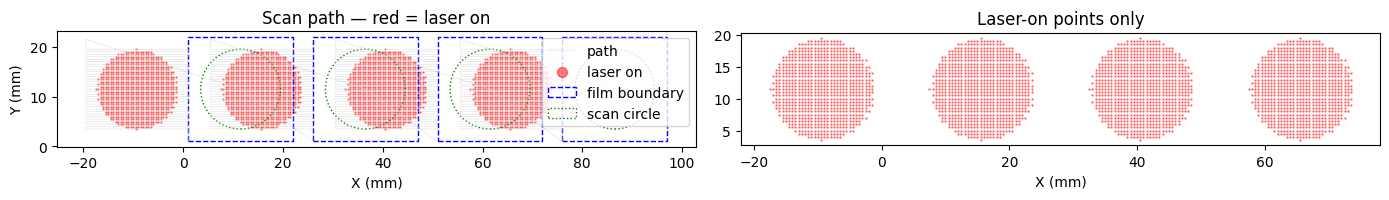

Total laser-on points: 3188


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

@dataclass
class FilmConfig:
    n_films: int
    film_width_mm: float
    film_height_mm: float
    gap_x_mm: float
    gap_y_mm: float
    films_per_row: int = 1
    edge_margin_mm: float = 1.0
    circular_scan: bool = False
    scan_radius_mm: float | None = None

    def get_radius(self) -> float:
        if self.scan_radius_mm is not None:
            return self.scan_radius_mm
        return min(self.scan_width_mm(), self.scan_height_mm()) / 2.0

    def scan_width_mm(self) -> float:
        return self.film_width_mm - 2 * self.edge_margin_mm

    def scan_height_mm(self) -> float:
        return self.film_height_mm - 2 * self.edge_margin_mm

    def film_origins(self) -> list[tuple[float, float]]:
        origins = []
        for i in range(self.n_films):
            row = i // self.films_per_row
            col = i %  self.films_per_row
            x = col * (self.film_width_mm + self.gap_x_mm) + self.edge_margin_mm
            y = row * (self.film_height_mm + self.gap_y_mm) + self.edge_margin_mm
            origins.append((x, y))
        return origins


class SimulatedScanner:
    """
    Replaces DensitometerScanner for testing without hardware.
    Records every point the laser was turned on.
    """

    def __init__(self, step_um: int = 25):
        self.step_mm = step_um / 1000.0
        self.current_x = 0.0
        self.current_y = 0.0
        self.laser_on = False
        self.laser_points: list[tuple[float, float]] = []
        self.all_points:   list[tuple[float, float]] = []  # every position visited

    def step(self, dx_mm: float = 0, dy_mm: float = 0):
        self.current_x += dx_mm
        self.current_y += dy_mm
        self.all_points.append((self.current_x, self.current_y))

    def measure(self) -> float:
        """Record point and return dummy signal."""
        if self.laser_on:
            self.laser_points.append((self.current_x, self.current_y))
        return 0.5   # dummy signal

    def raster_scan(self, x_steps: int, y_steps: int,
                    config: FilmConfig | None = None) -> tuple:
        positions = []
        signals = []

        radius = config.get_radius() if config and config.circular_scan else None

        half_x = (x_steps * self.step_mm) / 2.0
        half_y = (y_steps * self.step_mm) / 2.0

        self.laser_on = True

        for i in range(y_steps):
            if i > 0:
                self.step(dy_mm=self.step_mm)

            y_mm = (i * self.step_mm) - half_y

            # skip entire row if outside circle
            if radius is not None and abs(y_mm) > radius:
                continue

            direction = 1 if i % 2 == 0 else -1

            for j in range(x_steps):
                x_mm = (j * self.step_mm) - half_x

                in_circle = (radius is None or
                             (x_mm ** 2 + y_mm ** 2) <= radius ** 2)

                if in_circle:
                    sig = self.measure()
                    positions.append((self.current_x, self.current_y))
                    signals.append(sig)

                if j < x_steps - 1:
                    self.step(dx_mm=self.step_mm * direction)

        self.laser_on = False

        return np.array(positions), np.array(signals)

    def scan_all_films(self, config: FilmConfig) -> list[dict]:
        x_steps = int(config.scan_width_mm() / self.step_mm)
        y_steps = int(config.scan_height_mm() / self.step_mm)

        results = []
        current_x = 0.0
        current_y = 0.0

        for film_idx, (origin_x, origin_y) in enumerate(config.film_origins()):
            print(f"Scanning film {film_idx + 1} of {config.n_films} "
                f"at origin ({origin_x:.1f}, {origin_y:.1f}) mm")

            # move to this film's origin
            dx = origin_x - current_x
            dy = origin_y - current_y
            if dx != 0 or dy != 0:
                self.step(dx_mm=dx, dy_mm=dy)

            positions, signals = self.raster_scan(x_steps, y_steps, config)

            positions[:, 0] += origin_x
            positions[:, 1] += origin_y

            results.append({
                "film_index": film_idx,
                "origin": (origin_x, origin_y),
                "positions": positions,
                "signals": signals
            })

            # compute where the centre of this film is in absolute coords
            film_centre_x = origin_x + config.scan_width_mm()  / 2.0
            film_centre_y = origin_y + config.scan_height_mm() / 2.0

            # return to centre before moving to next film
            dx_to_centre = film_centre_x - self.current_x
            dy_to_centre = film_centre_y - self.current_y
            self.step(dx_mm=dx_to_centre, dy_mm=dy_to_centre)

            # next film move will be calculated from this known centre point
            current_x = film_centre_x
            current_y = film_centre_y

        return results


def plot_results(scanner: SimulatedScanner, config: FilmConfig):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ── left plot: all visited positions + laser-on points ──
    ax = axes[0]
    if scanner.all_points:
        all_arr = np.array(scanner.all_points)
        ax.plot(all_arr[:, 0], all_arr[:, 1],
                color="lightgray", linewidth=0.3, label="path")

    if scanner.laser_points:
        lp = np.array(scanner.laser_points)
        ax.scatter(lp[:, 0], lp[:, 1],
                   s=0.5, c="red", alpha=0.5, label="laser on")

    # draw film boundaries
    for origin_x, origin_y in config.film_origins():
        rect = plt.Rectangle(
            (origin_x, origin_y),
            config.scan_width_mm(),
            config.scan_height_mm(),
            linewidth=1, edgecolor="blue",
            facecolor="none", linestyle="--", label="film boundary"
        )
        ax.add_patch(rect)

        # draw circle if applicable
        if config.circular_scan:
            circle = plt.Circle(
                (origin_x + config.scan_width_mm()  / 2,
                 origin_y + config.scan_height_mm() / 2),
                config.get_radius(),
                color="green", fill=False,
                linewidth=1, linestyle=":", label="scan circle"
            )
            ax.add_patch(circle)

    ax.set_aspect("equal")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_title("Scan path — red = laser on")
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))   # deduplicate legend
    ax.legend(by_label.values(), by_label.keys(), markerscale=10)

    # ── right plot: laser-on points only as a 2D density image ──
    ax2 = axes[1]
    if scanner.laser_points:
        lp = np.array(scanner.laser_points)
        ax2.scatter(lp[:, 0], lp[:, 1], s=0.5, c="red", alpha=0.5)
    ax2.set_aspect("equal")
    ax2.set_xlabel("X (mm)")
    ax2.set_title("Laser-on points only")

    plt.tight_layout()
    plt.savefig("scan_preview.png", dpi=150)
    plt.show()
    print(f"Total laser-on points: {len(scanner.laser_points)}")


# ── run the simulation ───────────────────────────────────────

if __name__ == "__main__":
    film_width_mm = np.random.randint(10, 25)  # random film size for testing
    film_length_mm = film_width_mm 

    config = FilmConfig(
        n_films=np.random.randint(1, 25),  # random number of films for testing
        film_width_mm=film_width_mm,  # random film size for testing
        film_height_mm=film_length_mm,
        gap_x_mm=np.random.randint(1, 5),
        gap_y_mm=np.random.randint(1, 5),
        films_per_row=np.random.randint(1, 25),
        edge_margin_mm=1,
        circular_scan=True,
        scan_radius_mm=np.random.randint(1, min(film_width_mm, film_length_mm) // 2 - 1)
    )

    scanner = SimulatedScanner(step_um=500)  # 500 µm for fast simulation
                                             # change to 25 for real resolution
    results = scanner.scan_all_films(config)
    plot_results(scanner, config)